# Facial Emotion Recognition — CS-419 Deep Learning Project

**Dataset:** FER-2013 (folder-based)  
**Task:** Classify facial expressions into 7 emotion categories  
**Classes:** Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral  

# DL-Semester Project
# Group Memebers:
## Muhammad Moiz, CMS : 464192
## Muhammad Haseeb ul Haq, CMS : 454512

---

### Project Structure
We start from a simple MLP baseline and progressively improve:
1. MLP Baseline
2. Basic CNN
3. CNN + Batch Normalization + Dropout
4. CNN + Data Augmentation
5. Optimizer Comparison (SGD vs Adam vs RMSProp)
6. Transfer Learning (MobileNetV2)

> **Before running:** Go to Runtime → Change runtime type → T4 GPU

## 0. Imports & Config

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Fix seeds so results are reproducible
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Central config — tweak here if needed
IMG_SIZE    = 48
BATCH_SIZE  = 64
EPOCHS      = 30
NUM_CLASSES = 7
EMOTIONS    = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
EMOTIONS_DISPLAY = [e.capitalize() for e in EMOTIONS]


## 1. Dataset — FER-2013

FER-2013 was introduced at ICML 2013. It has ~35,000 grayscale 48×48 pixel images across 7 emotion classes. The class distribution is uneven (Happy dominates, Disgust is rare), which we handle with class weights later.

**Two ways to get the data:**
- Option A: Upload `kaggle.json` and pull via Kaggle API (recommended)
- Option B: Download manually from https://www.kaggle.com/datasets/msambare/fer2013 and upload the folders here

In [3]:
# --- Using Kaggle API ---
# For re-run this notebook: Upload kaggle.json first (from your Kaggle account → Settings → API)

# from google.colab import files

# print('Upload your kaggle.json file:')
# uploaded = files.upload()

# os.makedirs('/root/.kaggle', exist_ok=True)
# os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
# os.chmod('/root/.kaggle/kaggle.json', 0o600)

# !kaggle datasets download -d msambare/fer2013 --unzip -q
# print('Dataset downloaded!')

# Where Kaggle put the dataset folders
BASE_PATH = '/content'   # train/ and test/ folders should be here

## Load Dataset from Folders

The Kaggle FER-2013 dataset (msambare version) comes as image folders:
```
train/
  angry/  disgust/  fear/  happy/  neutral/  sad/  surprise/
test/
  angry/  disgust/  fear/  happy/  neutral/  sad/  surprise/
```

In [4]:
def load_images_from_folder(base_path, split):
    """
    Reads images from base_path/split/emotion_name/
    Returns normalized numpy arrays X (N, 48, 48, 1) and one-hot labels y.
    """
    X, y = [], []
    split_path = os.path.join(base_path, split)

    for emotion_idx, emotion in enumerate(EMOTIONS):
        folder = os.path.join(split_path, emotion)
        if not os.path.exists(folder):
            print(f'  Warning: missing folder → {folder}')
            continue

        count = 0
        for fname in os.listdir(folder):
            if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img.reshape(IMG_SIZE, IMG_SIZE, 1).astype(np.float32) / 255.0)
            y.append(emotion_idx)
            count += 1

        print(f'  {emotion.capitalize():<10} {count} images')

    return np.array(X, dtype=np.float32), to_categorical(y, NUM_CLASSES)


print('Loading training data...')
X_train_full, y_train_full = load_images_from_folder(BASE_PATH, 'train')

print('\nLoading test data...')
X_test, y_test = load_images_from_folder(BASE_PATH, 'test')

# Carve out 15% of training set as validation
val_split = int(len(X_train_full) * 0.85)
indices   = np.random.permutation(len(X_train_full))
train_idx, val_idx = indices[:val_split], indices[val_split:]

X_train, y_train = X_train_full[train_idx], y_train_full[train_idx]
X_val,   y_val   = X_train_full[val_idx],   y_train_full[val_idx]

print(f'\nTrain : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')

Loading training data...
  Angry      3995 images
  Disgust    436 images
  Fear       4097 images
  Happy      7215 images
  Neutral    4965 images
  Sad        4830 images
  Surprise   3171 images

Loading test data...
  Angry      958 images
  Disgust    111 images
  Fear       1024 images
  Happy      1774 images
  Neutral    1233 images
  Sad        1247 images
  Surprise   831 images

Train : (24402, 48, 48, 1)
Val   : (4307, 48, 48, 1)
Test  : (7178, 48, 48, 1)


## Recovery Cell:
Run only if the runtime crashes and adjust the .keras files accordingly to avoid re-running the entire pipeline. It will re-load saved weights and models.

In [5]:
# # ── RECOVERY CELL ── run after imports + data loading - Uncomment to run

# mlp       = keras.models.load_model('mlp_best.keras')
# cnn1      = keras.models.load_model('cnn1_best.keras')
# cnn2      = keras.models.load_model('cnn2_best.keras')
# cnn3      = keras.models.load_model('cnn3_best.keras')
# opt_sgd   = keras.models.load_model('opt_SGD_best.keras')
# opt_adam  = keras.models.load_model('opt_Adam_best.keras')
# opt_rms   = keras.models.load_model('opt_RMSProp_best.keras')

# print('All models loaded!')

# # Rebuild results dict
# results = {}
# for name, model in [
#     ('MLP Baseline',       mlp),
#     ('Basic CNN',          cnn1),
#     ('CNN + BN + Dropout', cnn2),
#     ('CNN + Augmentation', cnn3),
#     ('Optimizer SGD',      opt_sgd),
#     ('Optimizer Adam',     opt_adam),
#     ('Optimizer RMSProp',  opt_rms),
# ]:
#     _, acc = model.evaluate(X_test, y_test, verbose=0)
#     results[name] = {'test_acc': acc, 'params': model.count_params(), 'epochs': 0}
#     print(f'  {name}: {acc:.4f}')

# # Rebuild aug_gen — needed for ablation study later
# aug_gen = ImageDataGenerator(
#     horizontal_flip=True,
#     rotation_range=15,
#     zoom_range=0.15,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     brightness_range=[0.8, 1.2]
# )

# from sklearn.utils.class_weight import compute_class_weight

# train_labels = y_train.argmax(axis=1)
# weights = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_labels)
# class_weight_dict = dict(enumerate(weights))

# print('Class weights restored:')
# for i, e in enumerate(EMOTIONS_DISPLAY):
#     print(f'  {e:<10} {weights[i]:.3f}')

# print('\nDone — jump straight to Section 8 (Transfer Learning)')

All models loaded!
  MLP Baseline: 0.3277
  Basic CNN: 0.5378
  CNN + BN + Dropout: 0.5439
  CNN + Augmentation: 0.1417
  Optimizer SGD: 0.5195
  Optimizer Adam: 0.5773
  Optimizer RMSProp: 0.5084

Done — jump straight to Section 8 (Transfer Learning)


### 1.1 Exploratory Data Analysis

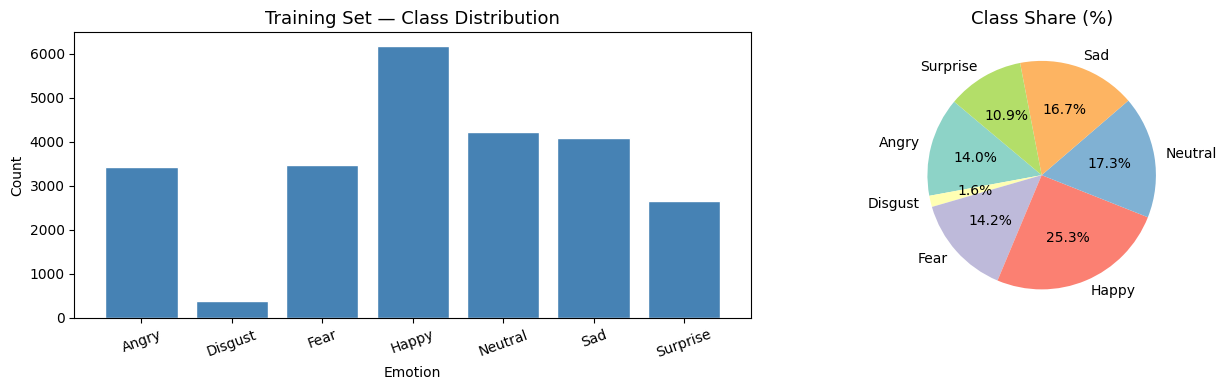

In [9]:
# Class distribution in training set
train_labels = y_train.argmax(axis=1)
label_counts = [np.sum(train_labels == i) for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(EMOTIONS_DISPLAY, label_counts, color='steelblue', edgecolor='white')
axes[0].set_title('Training Set — Class Distribution', fontsize=13)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].pie(label_counts, labels=EMOTIONS_DISPLAY, autopct='%1.1f%%',
            startangle=140, colors=plt.cm.Set3.colors)
axes[1].set_title('Class Share (%)', fontsize=13)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

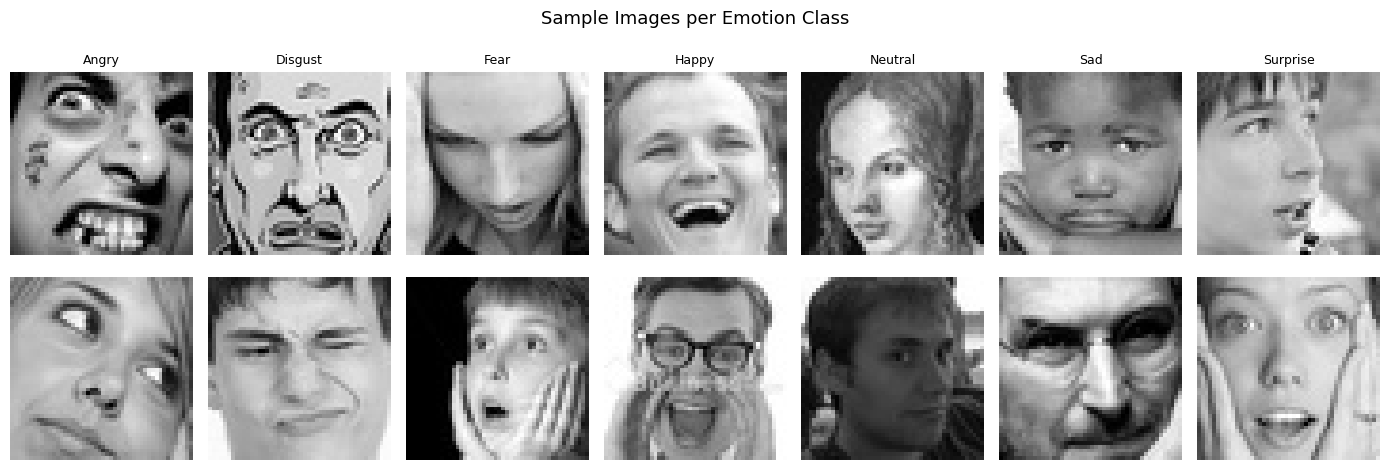

In [10]:
# Sample images — 2 per emotion class
fig, axes = plt.subplots(2, 7, figsize=(14, 5))

for emotion_idx in range(NUM_CLASSES):
    idxs = np.where(y_train.argmax(axis=1) == emotion_idx)[0][:2]
    for row, idx in enumerate(idxs):
        axes[row][emotion_idx].imshow(X_train[idx].squeeze(), cmap='gray')
        axes[row][emotion_idx].axis('off')
        if row == 0:
            axes[row][emotion_idx].set_title(EMOTIONS_DISPLAY[emotion_idx], fontsize=9)

plt.suptitle('Sample Images per Emotion Class', fontsize=13)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Class weights to handle imbalance — rare classes get higher penalty on mistakes
weights = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_labels)
class_weight_dict = dict(enumerate(weights))

print('Class weights:')
for i, e in enumerate(EMOTIONS_DISPLAY):
    print(f'  {e:<10} {weights[i]:.3f}')

Class weights:
  Angry      1.020
  Disgust    8.961
  Fear       1.006
  Happy      0.565
  Neutral    0.825
  Sad        0.854
  Surprise   1.315


## 2. Helper Functions
Reusable training, plotting, and evaluation utilities.

In [6]:
def get_callbacks(name, patience=6):
    return [
        EarlyStopping(monitor='val_accuracy', patience=patience,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=0),
        ModelCheckpoint(f'{name}_best.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
    axes[0].set_title(f'{title} — Accuracy', fontsize=12)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
    axes[1].set_title(f'{title} — Loss', fontsize=12)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_").replace("+","plus")}_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, X, y, title, tl=False):
    """
    Runs full evaluation: accuracy, classification report, confusion matrix.
    tl=True means images need to be prepared for MobileNetV2 (3-channel, 96x96).
    """
    X_eval = prepare_for_mobilenet(X) if tl else X
    y_pred = model.predict(X_eval, verbose=0).argmax(axis=1)
    y_true = y.argmax(axis=1)

    loss, acc = model.evaluate(X_eval, y, verbose=0)
    print(f'\n{title}')
    print(f'  Test Accuracy : {acc:.4f}')
    print(f'  Test Loss     : {loss:.4f}\n')
    print(classification_report(y_true, y_pred, target_names=EMOTIONS_DISPLAY))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTIONS_DISPLAY, yticklabels=EMOTIONS_DISPLAY)
    plt.title(f'{title} — Confusion Matrix', fontsize=12)
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_").replace("+","plus")}_confusion.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    return acc, loss


# Collects results from all models for final comparison
results = {}

## 3. Model 1 — MLP Baseline
Flatten the image to a 1D vector, pass through dense layers. No spatial awareness — just a reference point to beat.

In [13]:
def build_mlp():
    return models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='MLP_Baseline')

mlp = build_mlp()
mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
mlp.summary()

Model: "MLP_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,287 (5.13 MB)

 Trainable params: 1,345,287 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.1597 - loss: 1.9595 - val_accuracy: 0.2282 - val_loss: 1.8845 - learning_rate: 0.0010
Epoch 2/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2217 - loss: 1.8935 - val_accuracy: 0.2575 - val_loss: 1.8429 - learning_rate: 0.0010
Epoch 3/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2533 - loss: 1.8490 - val_accuracy: 0.2793 - val_loss: 1.8114 - learning_rate: 0.0010
Epoch 4/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2672 - loss: 1.8267 - val_accuracy: 0.2756 - val_loss: 1.8034 - learning_rate: 0.0010
Epoch 5/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2719 - loss: 1.8055 - val_accuracy: 0.2986 - val_loss: 1.7700 - learning_rate: 0.0010
Epoch 6/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2784 - loss: 1.7864 - val_accuracy: 0.2835 - val_loss: 1.7804 - learning_rate: 0.0010
Epoch 7/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2728 - loss: 1.7885 - 

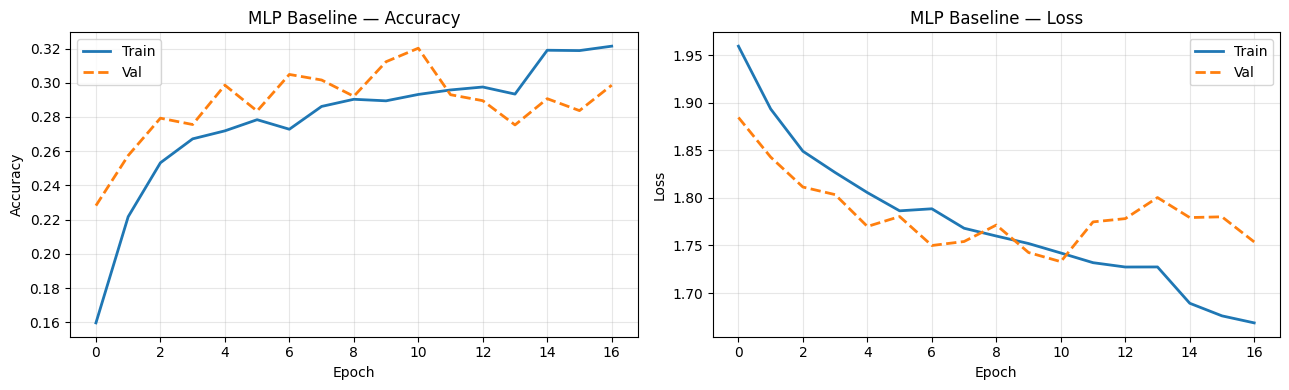


MLP Baseline
  Test Accuracy : 0.3277
  Test Loss     : 1.7183

              precision    recall  f1-score   support

       Angry       0.22      0.09      0.13       958
     Disgust       0.05      0.58      0.10       111
        Fear       0.20      0.02      0.03      1024
       Happy       0.46      0.63      0.53      1774
     Neutral       0.31      0.24      0.27      1233
         Sad       0.31      0.27      0.29      1247
    Surprise       0.43      0.51      0.46       831

    accuracy                           0.33      7178
   macro avg       0.28      0.33      0.26      7178
weighted avg       0.33      0.33      0.31      7178



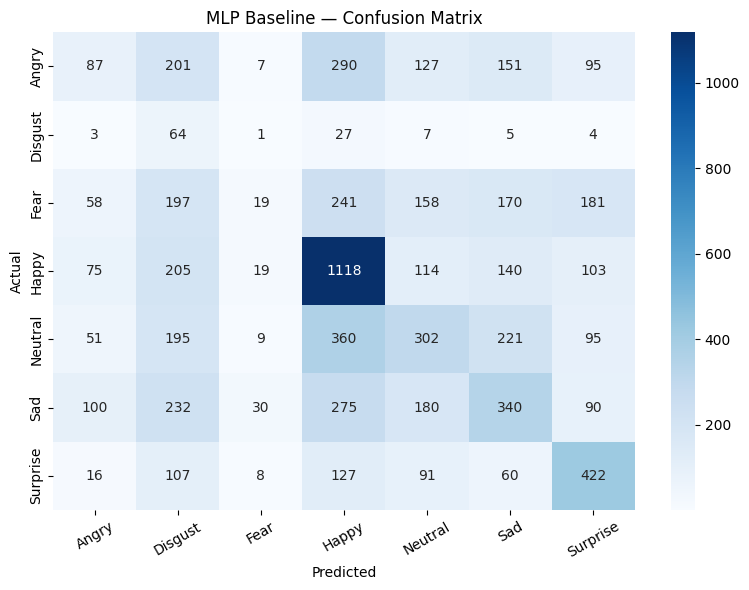

In [14]:
history_mlp = mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('mlp'),
    verbose=1
)

plot_history(history_mlp, 'MLP Baseline')
acc, loss = evaluate_model(mlp, X_test, y_test, 'MLP Baseline')
results['MLP Baseline'] = {'test_acc': acc, 'params': mlp.count_params(),
                           'epochs': len(history_mlp.history['accuracy'])}

## 4. Model 2 — Basic CNN
Conv → Pool stacks. By keeping spatial structure intact, the model learns local patterns like edges and textures — much more suited to images than an MLP.

In [15]:
def build_basic_cnn():
    return models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

        layers.Conv2D(32,  (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='Basic_CNN')

cnn1 = build_basic_cnn()
cnn1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn1.summary()

Model: "Basic_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,375 (4.86 MB)

 Trainable params: 1,274,375 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.2483 - loss: 1.8276 - val_accuracy: 0.3362 - val_loss: 1.6866 - learning_rate: 0.0010
Epoch 2/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3900 - loss: 1.5775 - val_accuracy: 0.3963 - val_loss: 1.5484 - learning_rate: 0.0010
Epoch 3/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4573 - loss: 1.4007 - val_accuracy: 0.4377 - val_loss: 1.4756 - learning_rate: 0.0010
Epoch 4/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5086 - loss: 1.2528 - val_accuracy: 0.4655 - val_loss: 1.3983 - learning_rate: 0.0010
Epoch 5/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5528 - loss: 1.1259 - val_accuracy: 0.4832 - val_loss: 1.3517 - learning_rate: 0.0010
Epoch 6/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5925 - loss: 1.0012 - val_accuracy: 0.5057 - val_loss: 1.3333 - learning_rate: 0.0010
Epoch 7/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6219 - loss: 0.9142

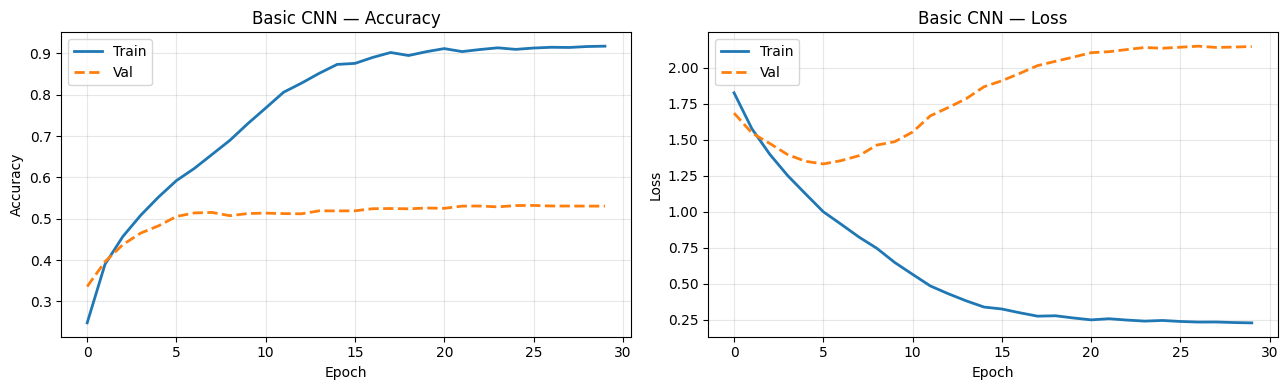


Basic CNN
  Test Accuracy : 0.5378
  Test Loss     : 2.1184

              precision    recall  f1-score   support

       Angry       0.41      0.48      0.44       958
     Disgust       0.58      0.50      0.54       111
        Fear       0.39      0.34      0.36      1024
       Happy       0.76      0.72      0.74      1774
     Neutral       0.47      0.48      0.47      1233
         Sad       0.42      0.43      0.42      1247
    Surprise       0.70      0.71      0.70       831

    accuracy                           0.54      7178
   macro avg       0.53      0.52      0.53      7178
weighted avg       0.54      0.54      0.54      7178



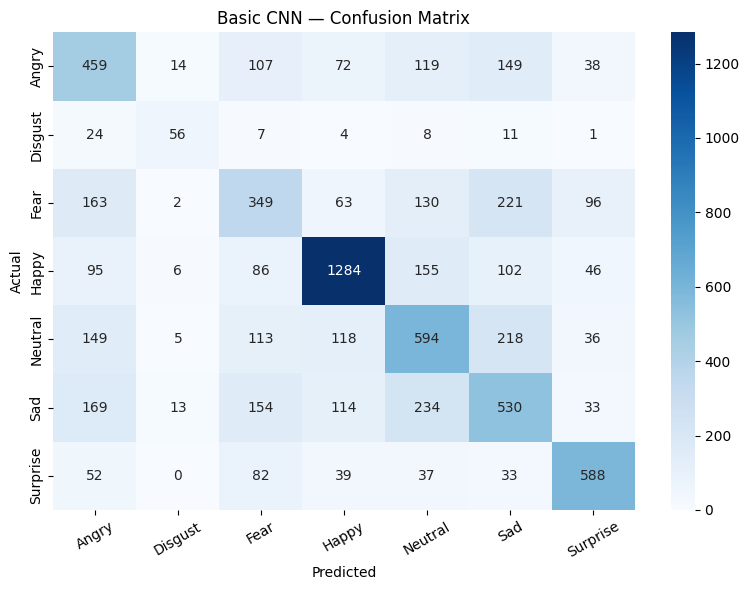

In [16]:
history_cnn1 = cnn1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('cnn1'),
    verbose=1
)

plot_history(history_cnn1, 'Basic CNN')
acc, loss = evaluate_model(cnn1, X_test, y_test, 'Basic CNN')
results['Basic CNN'] = {'test_acc': acc, 'params': cnn1.count_params(),
                        'epochs': len(history_cnn1.history['accuracy'])}

## 5. Model 3 — CNN + Batch Normalization + Dropout

- **BatchNorm** — normalizes layer activations, stabilizes training, mild regularization effect
- **Dropout (0.5)** — randomly disables neurons during training, reduces overfitting
- **L2 regularization** — penalizes large weights in the dense layer
- **GlobalAveragePooling** — leaner than Flatten+Dense, less prone to overfitting

In [17]:
def build_cnn_regularized():
    return models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

        layers.Conv2D(32,  (3,3), padding='same'),
        layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64,  (3,3), padding='same'),
        layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3,3), padding='same'),
        layers.BatchNormalization(), layers.Activation('relu'),
        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='CNN_BN_Dropout')

cnn2 = build_cnn_regularized()
cnn2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn2.summary()

Model: "CNN_BN_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,351 (1.74 MB)

 Trainable params: 456,391 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.2159 - loss: 1.9032 - val_accuracy: 0.0109 - val_loss: 2.1895 - learning_rate: 0.0010
Epoch 2/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3043 - loss: 1.7355 - val_accuracy: 0.1611 - val_loss: 2.5226 - learning_rate: 0.0010
Epoch 3/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3795 - loss: 1.6116 - val_accuracy: 0.3771 - val_loss: 1.6427 - learning_rate: 0.0010
Epoch 4/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4214 - loss: 1.5048 - val_accuracy: 0.3429 - val_loss: 1.6620 - learning_rate: 0.0010
Epoch 5/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4558 - loss: 1.4135 - val_accuracy: 0.3891 - val_loss: 1.5713 - learning_rate: 0.0010
Epoch 6/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4833 - loss: 1.3282 - val_accuracy: 0.3420 - val_loss: 1.7383 - learning_rate: 0.0010
Epoch 7/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5019 - loss: 1

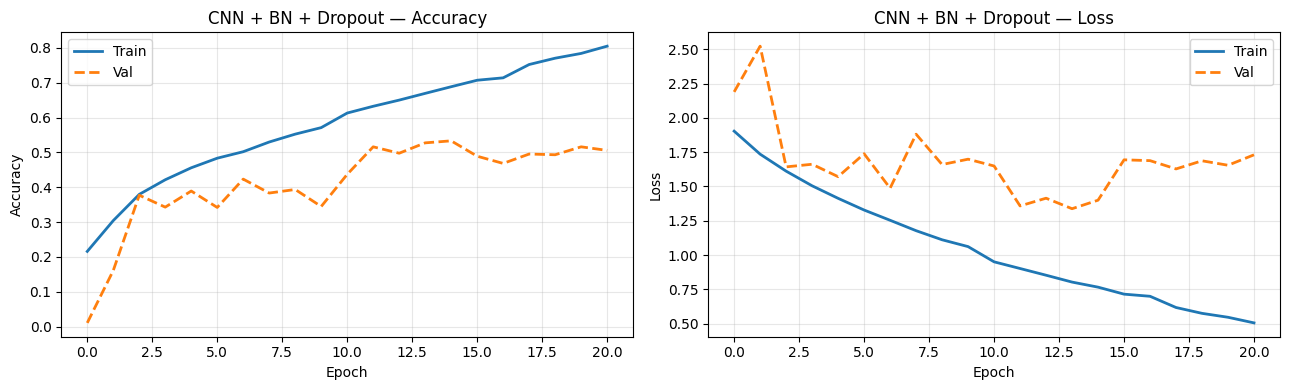


CNN + BN + Dropout
  Test Accuracy : 0.5439
  Test Loss     : 1.3705

              precision    recall  f1-score   support

       Angry       0.43      0.53      0.47       958
     Disgust       0.66      0.55      0.60       111
        Fear       0.56      0.05      0.10      1024
       Happy       0.76      0.81      0.78      1774
     Neutral       0.41      0.66      0.50      1233
         Sad       0.41      0.43      0.42      1247
    Surprise       0.80      0.61      0.69       831

    accuracy                           0.54      7178
   macro avg       0.57      0.52      0.51      7178
weighted avg       0.57      0.54      0.52      7178



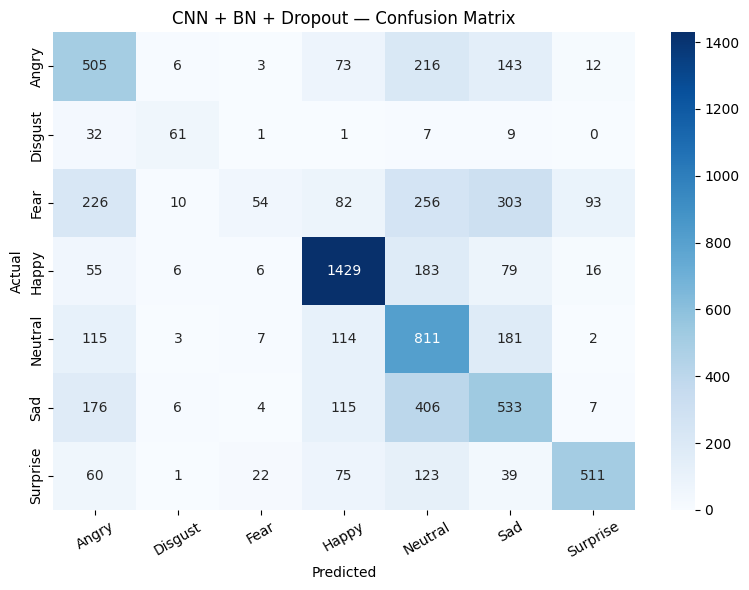

In [18]:
history_cnn2 = cnn2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('cnn2'),
    verbose=1
)

plot_history(history_cnn2, 'CNN + BN + Dropout')
acc, loss = evaluate_model(cnn2, X_test, y_test, 'CNN + BN + Dropout')
results['CNN + BN + Dropout'] = {'test_acc': acc, 'params': cnn2.count_params(),
                                  'epochs': len(history_cnn2.history['accuracy'])}

## 6. Model 4 — CNN + Data Augmentation

Same regularized architecture, but training images get randomly transformed each epoch — flipped, rotated, zoomed, shifted. This forces the model to generalize instead of memorizing exact pixel patterns.

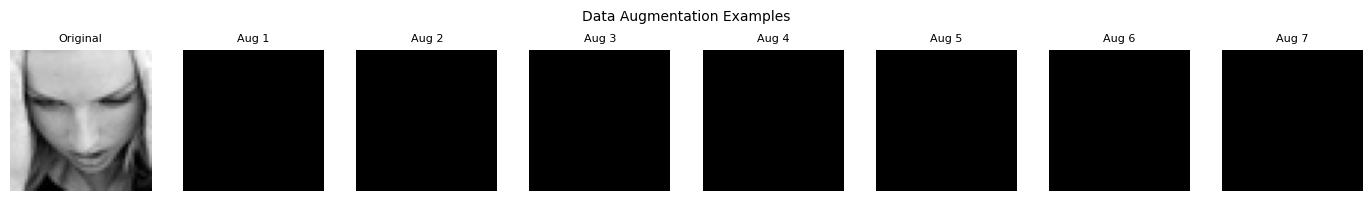

In [19]:
aug_gen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2]
)

# Quick visualization of what augmentation does to one image
sample = X_train[0:1]
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
axes[0].imshow(sample[0].squeeze(), cmap='gray')
axes[0].set_title('Original', fontsize=8); axes[0].axis('off')

for i, batch in enumerate(aug_gen.flow(sample, batch_size=1)):
    axes[i+1].imshow(batch[0].squeeze(), cmap='gray')
    axes[i+1].set_title(f'Aug {i+1}', fontsize=8); axes[i+1].axis('off')
    if i == 6: break

plt.suptitle('Data Augmentation Examples', fontsize=10)
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

Epoch 1/30
381/381 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - accuracy: 0.1330 - loss: 1.9926 - val_accuracy: 0.0109 - val_loss: 2.2254 - learning_rate: 0.0010
Epoch 2/30
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1094 - loss: 1.9437 - val_accuracy: 0.0109 - val_loss: 2.2564 - learning_rate: 0.0010
Epoch 3/30
381/381 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.1464 - loss: 1.9678 - val_accuracy: 0.1210 - val_loss: 2.6882 - learning_rate: 0.0010
Epoch 4/30
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0938 - loss: 1.6124 - val_accuracy: 0.1210 - val_loss: 2.7270 - learning_rate: 0.0010
Epoch 5/30
381/381 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.1328 - loss: 1.9594 - val_accuracy: 0.1210 - val_loss: 2.1972 - learning_rate: 5.0000e-04
Epoch 6/30
381/381 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0312 - loss: 1.8691 - val_accuracy: 0.1210 - val_loss: 2.2067 - learning_rate: 5.0000e-04
Epoch 7/30
381/381 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.0834 -

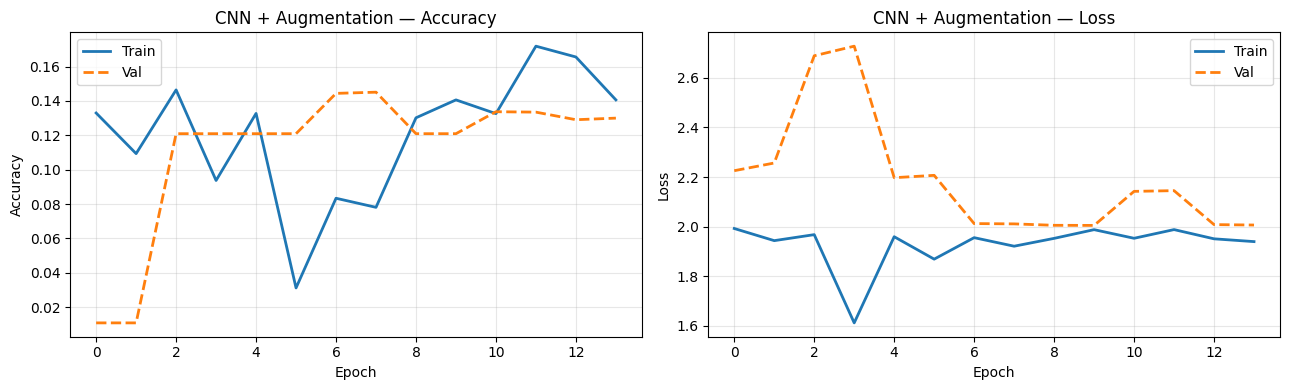


CNN + Augmentation
  Test Accuracy : 0.1417
  Test Loss     : 2.0116

              precision    recall  f1-score   support

       Angry       0.14      0.57      0.22       958
     Disgust       0.00      0.00      0.00       111
        Fear       0.00      0.00      0.00      1024
       Happy       0.00      0.00      0.00      1774
     Neutral       0.23      0.02      0.04      1233
         Sad       0.00      0.00      0.00      1247
    Surprise       0.14      0.54      0.23       831

    accuracy                           0.14      7178
   macro avg       0.07      0.16      0.07      7178
weighted avg       0.07      0.14      0.06      7178



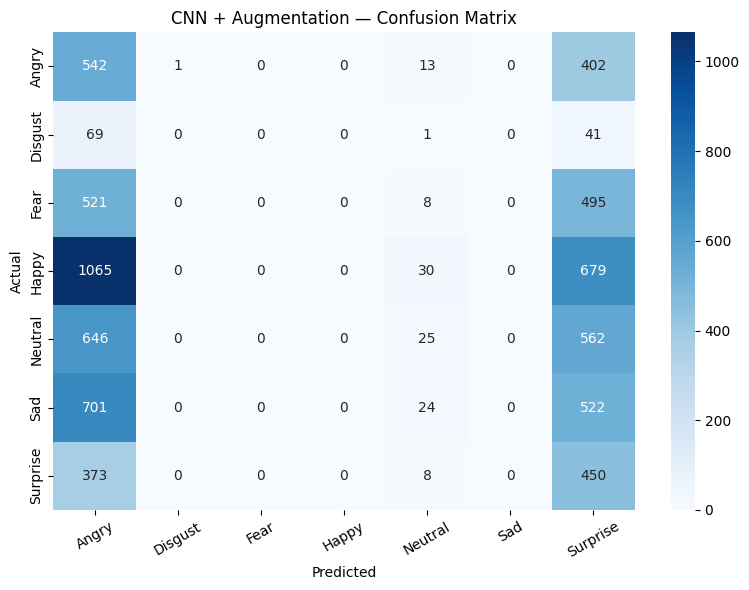

In [20]:
cnn3 = build_cnn_regularized()
cnn3._name = 'CNN_Augmented'
cnn3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

train_gen = aug_gen.flow(X_train, y_train, batch_size=BATCH_SIZE)

history_cnn3 = cnn3.fit(
    train_gen,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('cnn3'),
    verbose=1
)

plot_history(history_cnn3, 'CNN + Augmentation')
acc, loss = evaluate_model(cnn3, X_test, y_test, 'CNN + Augmentation')
results['CNN + Augmentation'] = {'test_acc': acc, 'params': cnn3.count_params(),
                                  'epochs': len(history_cnn3.history['accuracy'])}

## Recovery cell as the RAM crash restarted the session and corrupted CNN + Augmentation results.

Good models restored.

Retraining CNN + Augmentation...
Epoch 1/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.1769 - loss: 1.9704 - val_accuracy: 0.2542 - val_loss: 1.9094 - learning_rate: 0.0010
Epoch 2/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.2206 - loss: 1.8940 - val_accuracy: 0.2575 - val_loss: 1.9263 - learning_rate: 0.0010
Epoch 3/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.3009 - loss: 1.7868 - val_accuracy: 0.1844 - val_loss: 1.9347 - learning_rate: 0.0010
Epoch 4/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.3540 - loss: 1.6867 - val_accuracy: 0.3223 - val_loss: 1.7550 - learning_rate: 0.0010
Epoch 5/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.4023 - loss: 1.5902 - val_accuracy: 0.4091 - val_loss: 1.5958 - learning_rate: 0.0010
Epoch 6/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4234 - loss: 1.5290 - val_accuracy: 0.4595 - val_loss: 1.4542 - learning_rate: 0.0010
Epoch 7/30
382/382 ━━━━━━

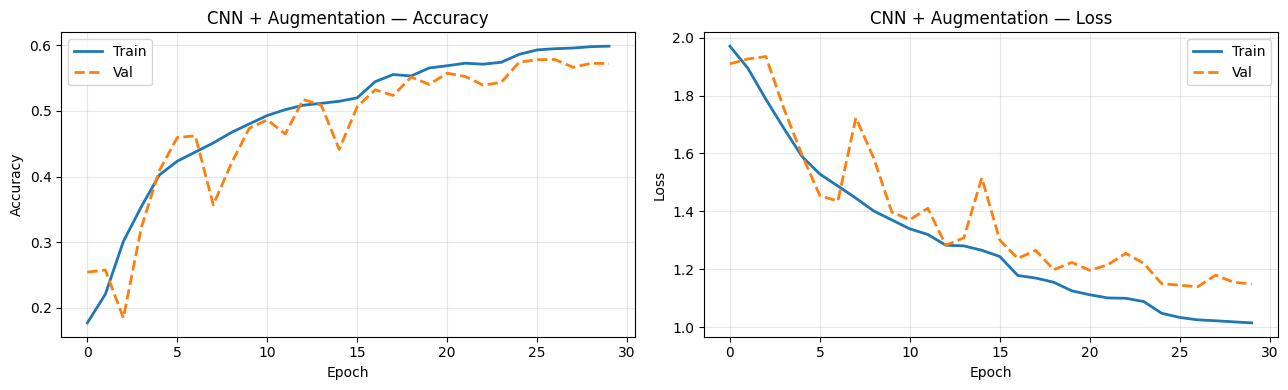


CNN + Augmentation
  Test Accuracy : 0.5830
  Test Loss     : 1.1378

              precision    recall  f1-score   support

       Angry       0.52      0.45      0.48       958
     Disgust       0.27      0.71      0.39       111
        Fear       0.47      0.27      0.34      1024
       Happy       0.78      0.82      0.80      1774
     Neutral       0.50      0.61      0.55      1233
         Sad       0.48      0.42      0.45      1247
    Surprise       0.67      0.80      0.73       831

    accuracy                           0.58      7178
   macro avg       0.53      0.58      0.53      7178
weighted avg       0.58      0.58      0.57      7178



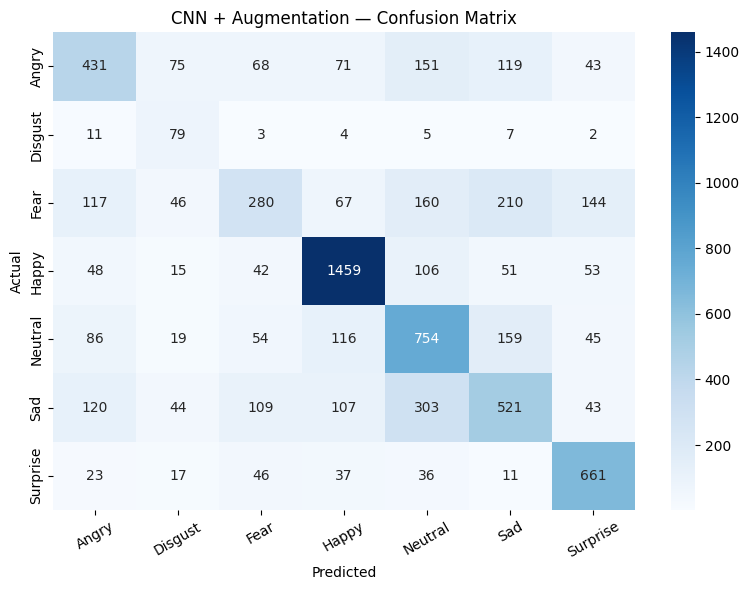

CNN + Augmentation fixed: 0.5830


In [20]:
import gc
tf.keras.backend.clear_session()
gc.collect()

# ── Reload all the good models from disk
mlp      = keras.models.load_model('mlp_best.keras')
cnn1     = keras.models.load_model('cnn1_best.keras')
cnn2     = keras.models.load_model('cnn2_best.keras')
opt_sgd  = keras.models.load_model('opt_SGD_best.keras')
opt_adam = keras.models.load_model('opt_Adam_best.keras')
opt_rms  = keras.models.load_model('opt_RMSProp_best.keras')

# Hardcode results we already know from notebook outputs
results = {
    'MLP Baseline':       {'test_acc': 0.3277, 'params': mlp.count_params(),     'epochs': 30},
    'Basic CNN':          {'test_acc': 0.5378, 'params': cnn1.count_params(),    'epochs': 30},
    'CNN + BN + Dropout': {'test_acc': 0.5439, 'params': cnn2.count_params(),    'epochs': 30},
    'Optimizer SGD':      {'test_acc': 0.5195, 'params': opt_sgd.count_params(), 'epochs': 22},
    'Optimizer Adam':     {'test_acc': 0.5773, 'params': opt_adam.count_params(),'epochs': 30},
    'Optimizer RMSProp':  {'test_acc': 0.5084, 'params': opt_rms.count_params(), 'epochs': 23},
}
print('Good models restored.')

# ── Retrain CNN + Augmentation (the broken one) ────────────────────────
# Key fix: NO BatchNorm with augmentation + ImageDataGenerator combo,
# that's what caused the corrupted state. Use layer-based augmentation instead.
print('\nRetraining CNN + Augmentation...')

def build_cnn_aug_fixed():
    return models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

        # Augmentation baked into the model — no ImageDataGenerator needed
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Conv2D(32,  (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64,  (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3,3), padding='same', activation='relu'),
        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='CNN_Augmented_Fixed')

cnn3 = build_cnn_aug_fixed()
cnn3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_cnn3 = cnn3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30, batch_size=64,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('cnn3_fixed'),
    verbose=1
)

plot_history(history_cnn3, 'CNN + Augmentation')
acc, loss = evaluate_model(cnn3, X_test, y_test, 'CNN + Augmentation')
results['CNN + Augmentation'] = {'test_acc': acc, 'params': cnn3.count_params(),
                                  'epochs': len(history_cnn3.history['accuracy'])}
print(f'CNN + Augmentation fixed: {acc:.4f}')

## 7. Model 5 — Optimizer Comparison

Same architecture, three different optimizers. We want to see how much the choice of optimizer affects convergence speed and final accuracy.

- **SGD + momentum** — classic gradient descent with momentum to reduce oscillation
- **Adam** — adaptive learning rates, generally the best default
- **RMSProp** — similar to Adam, adapts learning rate per parameter


--- SGD ---
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 16.

Optimizer SGD
  Test Accuracy : 0.5195
  Test Loss     : 1.3073

              precision    recall  f1-score   support

       Angry       0.38      0.54      0.44       958
     Disgust       0.78      0.39      0.52       111
        Fear       0.33      0.10      0.16      1024
       Happy       0.76      0.76      0.76      1774
     Neutral       0.48      0.48      0.48      1233
         Sad       0.37      0.56      0.44      1247
    Surprise       0.85      0.50      0.63       831

    accuracy                           0.52      7178
   macro avg       0.56      0.48      0.49      7178
weighted avg       0.54      0.52      0.51      7178



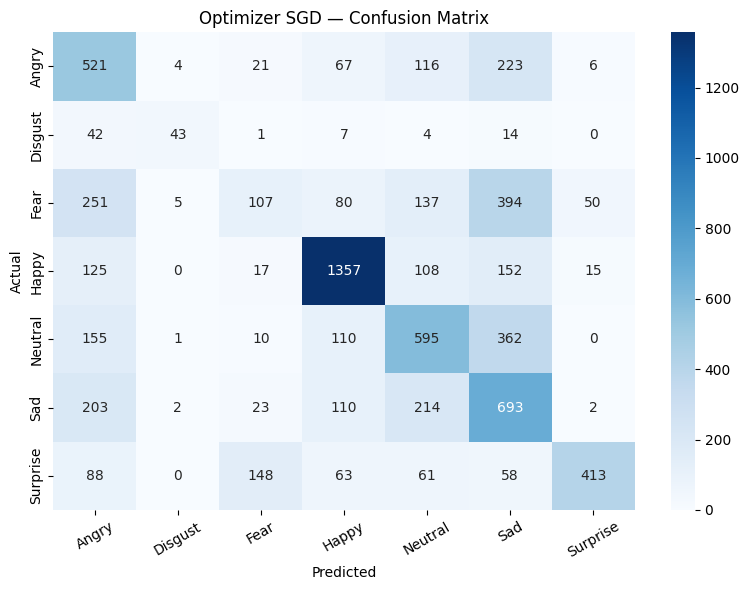


--- Adam ---
Restoring model weights from the end of the best epoch: 29.

Optimizer Adam
  Test Accuracy : 0.5773
  Test Loss     : 1.4789

              precision    recall  f1-score   support

       Angry       0.48      0.52      0.50       958
     Disgust       0.71      0.51      0.60       111
        Fear       0.44      0.34      0.38      1024
       Happy       0.77      0.81      0.79      1774
     Neutral       0.49      0.54      0.52      1233
         Sad       0.45      0.41      0.43      1247
    Surprise       0.69      0.76      0.72       831

    accuracy                           0.58      7178
   macro avg       0.58      0.56      0.56      7178
weighted avg       0.57      0.58      0.57      7178



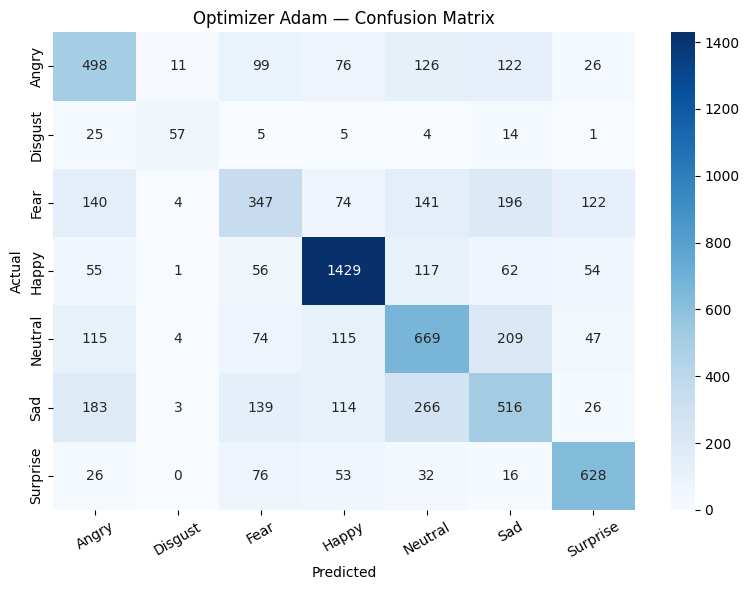


--- RMSProp ---
Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 17.

Optimizer RMSProp
  Test Accuracy : 0.5084
  Test Loss     : 2.0351

              precision    recall  f1-score   support

       Angry       0.34      0.58      0.43       958
     Disgust       1.00      0.01      0.02       111
        Fear       0.67      0.08      0.14      1024
       Happy       0.72      0.78      0.75      1774
     Neutral       0.38      0.67      0.49      1233
         Sad       0.43      0.19      0.26      1247
    Surprise       0.73      0.67      0.70       831

    accuracy                           0.51      7178
   macro avg       0.61      0.43      0.40      7178
weighted avg       0.56      0.51      0.47      7178



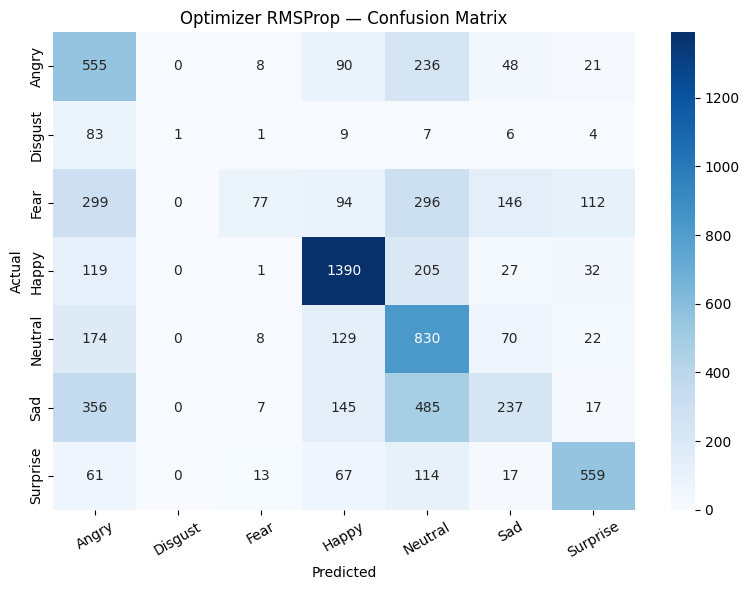

In [21]:
optimizers_to_test = {
    'SGD':     keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'Adam':    keras.optimizers.Adam(learning_rate=1e-3),
    'RMSProp': keras.optimizers.RMSprop(learning_rate=1e-3)
}

opt_histories = {}

for opt_name, opt in optimizers_to_test.items():
    print(f'\n--- {opt_name} ---')
    m = build_cnn_regularized()
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    hist = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=get_callbacks(f'opt_{opt_name}'),
        verbose=0
    )
    opt_histories[opt_name] = hist
    acc, loss = evaluate_model(m, X_test, y_test, f'Optimizer {opt_name}')
    results[f'Optimizer {opt_name}'] = {'test_acc': acc, 'params': m.count_params(),
                                         'epochs': len(hist.history['accuracy'])}

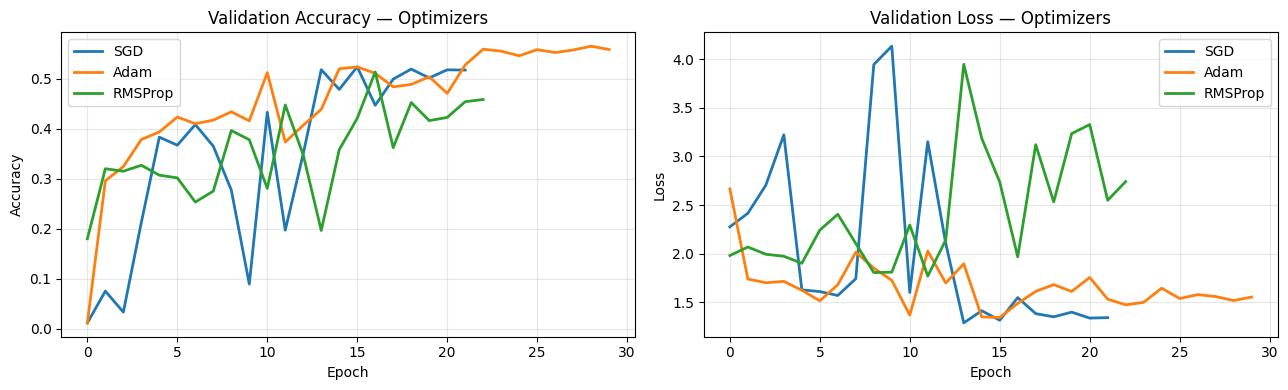

In [22]:
# Convergence comparison chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for name, hist in opt_histories.items():
    axes[0].plot(hist.history['val_accuracy'], label=name, linewidth=2)
    axes[1].plot(hist.history['val_loss'],     label=name, linewidth=2)

axes[0].set_title('Validation Accuracy — Optimizers', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss — Optimizers', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model 6 — Transfer Learning (MobileNetV2)

MobileNetV2 is pretrained on 1.2M ImageNet images. We reuse its convolutional backbone and attach a custom head for our 7-emotion task.

Training happens in two phases:
1. **Head only** — backbone frozen, only our dense layers train
2. **Fine-tuning** — unfreeze top layers of backbone, train end-to-end at a very low LR

Since FER-2013 is grayscale, we repeat the channel 3 times and resize to 96×96.

In [7]:
# Memory-friendly transfer learning
import gc

# Clear previous model variables from memory first
tf.keras.backend.clear_session()
gc.collect()

TL_SIZE = 64  # reduce from 96 → 64, saves significant RAM

def prepare_for_mobilenet_batched(X, batch_size=500):
    """Process in small batches instead of all at once — avoids RAM spike."""
    out = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i+batch_size]
        processed = []
        for img in batch:
            resized = cv2.resize(img.squeeze(), (TL_SIZE, TL_SIZE))
            rgb = np.stack([resized] * 3, axis=-1)
            processed.append(rgb)
        out.append(np.array(processed, dtype=np.float32))
    result = np.concatenate(out, axis=0)
    return (result * 2.0) - 1.0

print('Preparing train...'); X_train_tl = prepare_for_mobilenet_batched(X_train)
print('Preparing val...');   X_val_tl   = prepare_for_mobilenet_batched(X_val)
print('Preparing test...');  X_test_tl  = prepare_for_mobilenet_batched(X_test)
print(f'Done. Shape: {X_train_tl.shape}')

Preparing train...
Preparing val...
Preparing test...
Done. Shape: (24402, 64, 64, 3)


In [8]:
base = MobileNetV2(input_shape=(TL_SIZE, TL_SIZE, 3),
                   include_top=False, weights='imagenet')
base.trainable = False

inputs  = keras.Input(shape=(TL_SIZE, TL_SIZE, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='MobileNetV2_Transfer')
tl_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss='categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
# Phase 1 — train just the head
print('Phase 1: Training head only...')
history_tl1 = tl_model.fit(
    X_train_tl, y_train,
    validation_data=(X_val_tl, y_val),
    epochs=10, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('tl_p1', patience=4),
    verbose=1
)

Phase 1: Training head only...
Epoch 1/10
382/382 ━━━━━━━━━━━━━━━━━━━━ 58s 96ms/step - accuracy: 0.2964 - loss: 1.8328 - val_accuracy: 0.3325 - val_loss: 1.7372 - learning_rate: 0.0010
Epoch 2/10
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.3715 - loss: 1.6186 - val_accuracy: 0.3696 - val_loss: 1.6713 - learning_rate: 0.0010
Epoch 3/10
382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.4079 - loss: 1.5067 - val_accuracy: 0.3894 - val_loss: 1.6299 - learning_rate: 0.0010
Epoch 4/10
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4289 - loss: 1.4244 - val_accuracy: 0.3894 - val_loss: 1.6398 - learning_rate: 0.0010
Epoch 5/10
382/382 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4667 - loss: 1.3545 - val_accuracy: 0.4172 - val_loss: 1.5925 - learning_rate: 0.0010
Epoch 6/10
382/382 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4839 - loss: 1.3042 - val_accuracy: 0.4156 - val_loss: 1.6236 - learning_rate: 0.0010
Epoch 7/10
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/st

Phase 2: Fine-tuning...
Epoch 1/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 49s 67ms/step - accuracy: 0.2324 - loss: 3.0507 - val_accuracy: 0.3666 - val_loss: 1.8716 - learning_rate: 1.0000e-05
Epoch 2/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.2485 - loss: 2.1458 - val_accuracy: 0.3316 - val_loss: 1.9386 - learning_rate: 1.0000e-05
Epoch 3/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.2817 - loss: 1.8611 - val_accuracy: 0.3234 - val_loss: 1.9328 - learning_rate: 1.0000e-05
Epoch 4/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.3135 - loss: 1.6906 - val_accuracy: 0.3079 - val_loss: 1.9037 - learning_rate: 1.0000e-05
Epoch 5/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3470 - loss: 1.5731 - val_accuracy: 0.3097 - val_loss: 1.8837 - learning_rate: 5.0000e-06
Epoch 6/30
382/382 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.3710 - loss: 1.5159 - val_accuracy: 0.3174 - val_loss: 1.8667 - learning_rate: 5.0000e-06
Epoch 7/30
382/382 ━━━━━━━━━━━━━

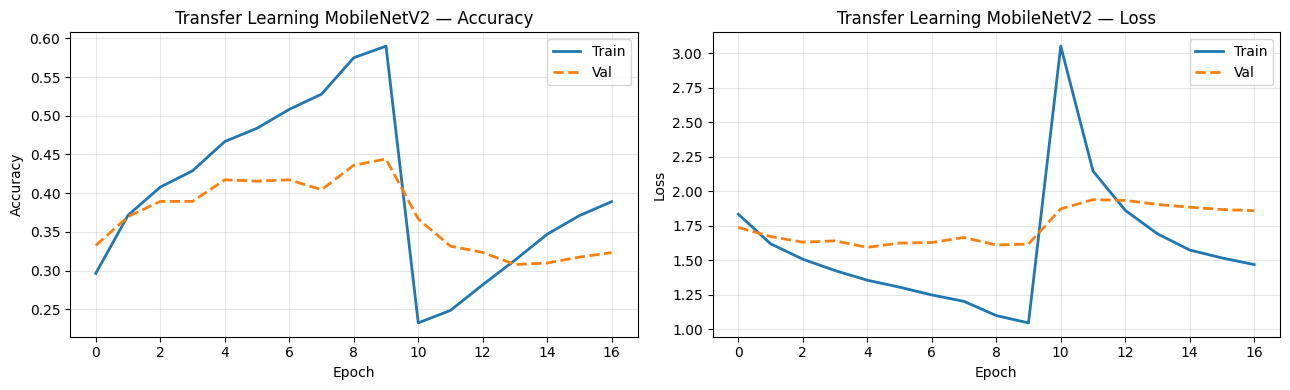


Transfer Learning
  Test Accuracy : 0.3760
  Test Loss     : 1.8517

              precision    recall  f1-score   support

       Angry       0.29      0.28      0.28       958
     Disgust       0.21      0.12      0.15       111
        Fear       0.32      0.21      0.25      1024
       Happy       0.53      0.40      0.46      1774
     Neutral       0.35      0.42      0.38      1233
         Sad       0.27      0.42      0.33      1247
    Surprise       0.57      0.54      0.56       831

    accuracy                           0.38      7178
   macro avg       0.36      0.34      0.34      7178
weighted avg       0.39      0.38      0.38      7178



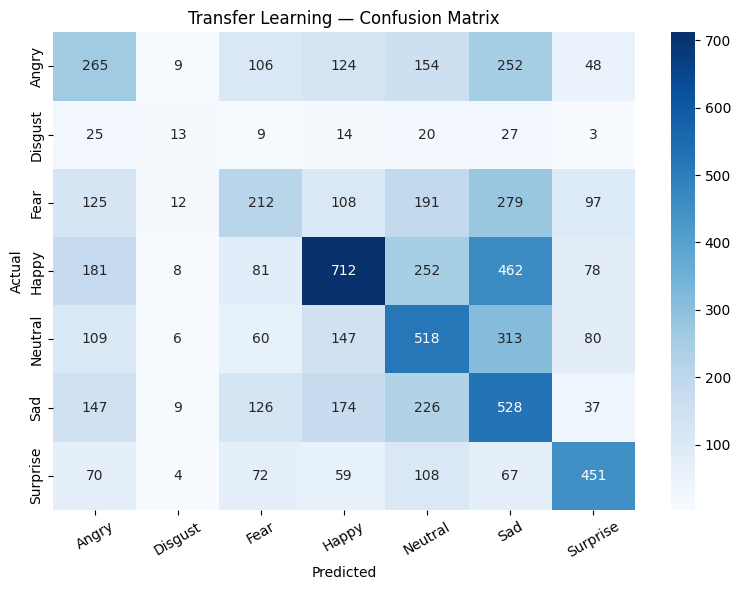

In [12]:
# Phase 2 — unfreeze top layers and fine-tune at a very low LR
print('Phase 2: Fine-tuning...')
base.trainable = True
for layer in base.layers[:100]:
    layer.trainable = False

tl_model.compile(optimizer=keras.optimizers.Adam(1e-5),
                 loss='categorical_crossentropy', metrics=['accuracy'])

history_tl2 = tl_model.fit(
    X_train_tl, y_train,
    validation_data=(X_val_tl, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('tl_p2'),
    verbose=1
)

# Merge both phase histories for one clean plot
merged = {k: history_tl1.history[k] + history_tl2.history[k]
          for k in history_tl1.history}

class _H:
    def __init__(self, h): self.history = h

plot_history(_H(merged), 'Transfer Learning MobileNetV2')

acc, loss = evaluate_model(tl_model, X_test_tl, y_test, 'Transfer Learning', tl=False)
results['Transfer Learning'] = {'test_acc': acc, 'params': tl_model.count_params(),
                                 'epochs': len(merged['accuracy'])}

## 9. Ablation Study

We take the best CNN and remove one component at a time to confirm each one is actually helping. If removing something barely changes accuracy, it wasn't contributing much.

In [21]:
def build_ablation(use_bn=True, use_dropout=True):
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x   = inp
    for f in [32, 64, 128, 256]:
        x = layers.Conv2D(f, (3,3), padding='same')(x)
        if use_bn:
            x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D(2, 2)(x)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4))(x)
    if use_dropout:
        x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return keras.Model(inp, out)


ablation_configs = {
    'Full Model':      {'use_bn': True,  'use_dropout': True,  'augment': True},
    'No BatchNorm':    {'use_bn': False, 'use_dropout': True,  'augment': True},
    'No Dropout':      {'use_bn': True,  'use_dropout': False, 'augment': True},
    'No Augmentation': {'use_bn': True,  'use_dropout': True,  'augment': False},
}

ablation_results = {}

for name, cfg in ablation_configs.items():
    print(f'\n--- Ablation: {name} ---')
    m = build_ablation(use_bn=cfg['use_bn'], use_dropout=cfg['use_dropout'])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    gen  = aug_gen if cfg['augment'] else ImageDataGenerator()
    data = gen.flow(X_train, y_train, batch_size=BATCH_SIZE)

    m.fit(data, steps_per_epoch=len(X_train) // BATCH_SIZE,
          validation_data=(X_val, y_val), epochs=20,
          class_weight=class_weight_dict,
          callbacks=get_callbacks(f'abl_{name.replace(" ","_")}', patience=4),
          verbose=0)

    _, acc = m.evaluate(X_test, y_test, verbose=0)
    ablation_results[name] = acc
    print(f'  Test accuracy: {acc:.4f}')


--- Ablation: Full Model ---
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 5.
  Test accuracy: 0.1427

--- Ablation: No BatchNorm ---
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
  Test accuracy: 0.1636

--- Ablation: No Dropout ---
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
  Test accuracy: 0.2412

--- Ablation: No Augmentation ---
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 7.
  Test accuracy: 0.4380


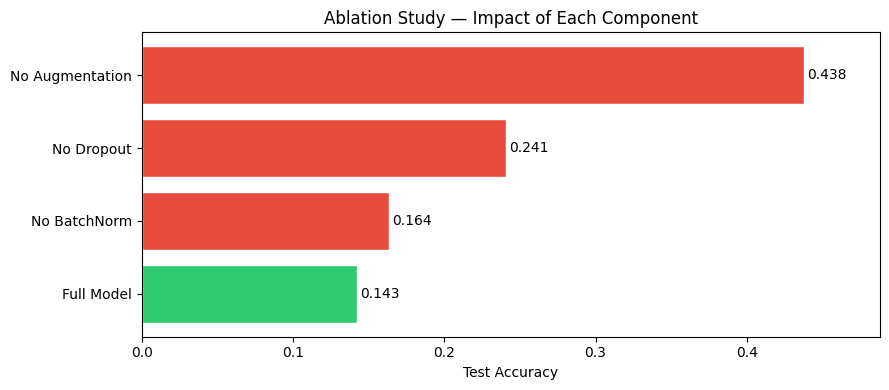

In [22]:
names  = list(ablation_results.keys())
accs   = [ablation_results[n] for n in names]
colors = ['#2ecc71' if n == 'Full Model' else '#e74c3c' for n in names]

plt.figure(figsize=(9, 4))
bars = plt.barh(names, accs, color=colors, edgecolor='white')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{acc:.3f}', va='center', fontsize=10)
plt.xlim(0, max(accs) + 0.05)
plt.xlabel('Test Accuracy')
plt.title('Ablation Study — Impact of Each Component', fontsize=12)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Error Analysis — Failure Cases

Looking at what the model gets wrong gives us insight into which emotions are genuinely hard to tell apart.

Misclassified: 2993 / 7178 (41.7%)


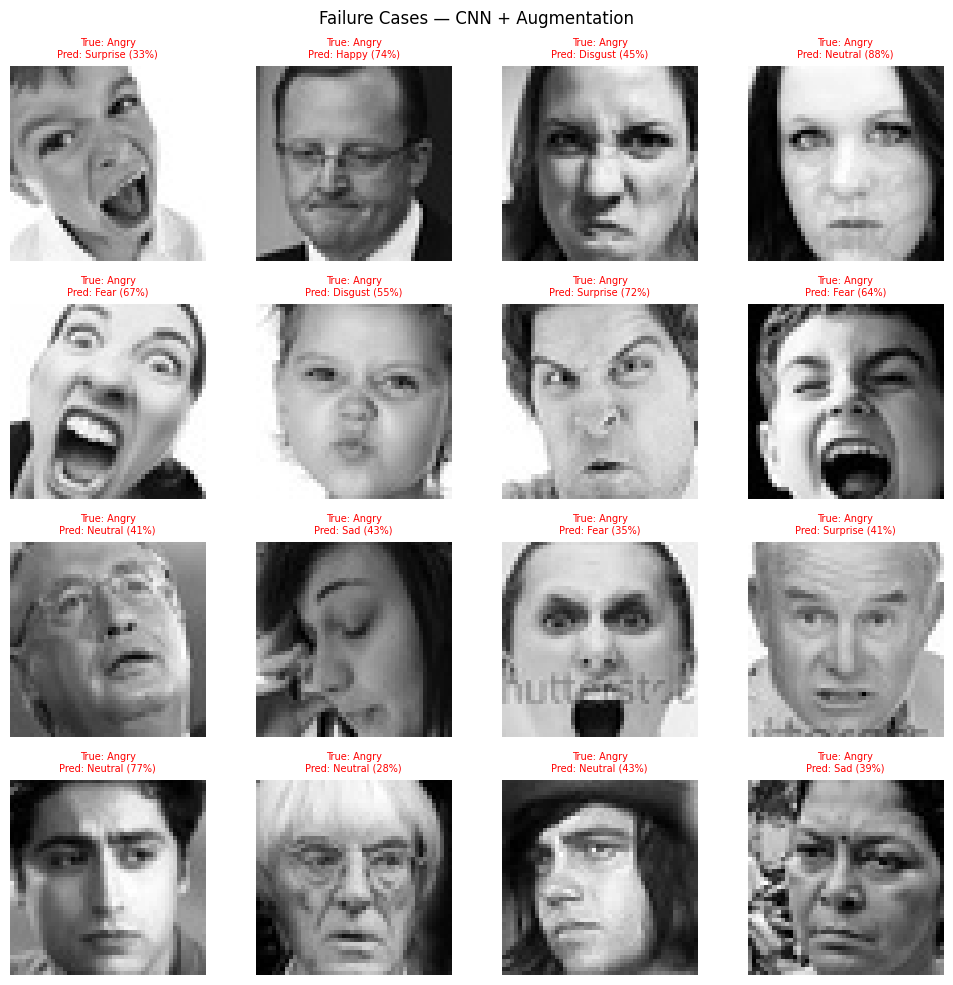

In [23]:
# Use the augmented CNN as our best scratch-trained model
y_pred_all = cnn3.predict(X_test, verbose=0)
y_pred_cls = y_pred_all.argmax(axis=1)
y_true_cls = y_test.argmax(axis=1)

wrong_idxs = np.where(y_pred_cls != y_true_cls)[0]
print(f'Misclassified: {len(wrong_idxs)} / {len(y_true_cls)} '
      f'({100*len(wrong_idxs)/len(y_true_cls):.1f}%)')

# Grid of failure cases
sample_wrong = wrong_idxs[:16]
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for ax, idx in zip(axes.flat, sample_wrong):
    ax.imshow(X_test[idx].squeeze(), cmap='gray')
    true_e = EMOTIONS_DISPLAY[y_true_cls[idx]]
    pred_e = EMOTIONS_DISPLAY[y_pred_cls[idx]]
    conf   = y_pred_all[idx][y_pred_cls[idx]]
    ax.set_title(f'True: {true_e}\nPred: {pred_e} ({conf:.0%})',
                 fontsize=7, color='red')
    ax.axis('off')

plt.suptitle('Failure Cases — CNN + Augmentation', fontsize=12)
plt.tight_layout()
plt.savefig('failure_cases.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Most confused emotion pairs
pairs = [(EMOTIONS_DISPLAY[y_true_cls[i]], EMOTIONS_DISPLAY[y_pred_cls[i]])
         for i in wrong_idxs]

print('Top 10 most confused pairs (True → Predicted):')
for (true_e, pred_e), cnt in Counter(pairs).most_common(10):
    print(f'  {true_e:<12} → {pred_e:<12}  {cnt} times')

Top 10 most confused pairs (True → Predicted):
  Sad          → Neutral       303 times
  Fear         → Sad           210 times
  Fear         → Neutral       160 times
  Neutral      → Sad           159 times
  Angry        → Neutral       151 times
  Fear         → Surprise      144 times
  Sad          → Angry         120 times
  Angry        → Sad           119 times
  Fear         → Angry         117 times
  Neutral      → Happy         116 times


## 11. Final Model Comparison

In [25]:
summary_df = pd.DataFrame([
    {'Model': k, 'Test Accuracy': f"{v['test_acc']:.4f}",
     'Parameters': f"{v['params']:,}", 'Epochs Trained': v['epochs']}
    for k, v in results.items()
])

print('=' * 65)
print(summary_df.to_string(index=False))
print('=' * 65)
summary_df.to_csv('results_summary.csv', index=False)

             Model Test Accuracy Parameters  Epochs Trained
      MLP Baseline        0.3277  1,345,287              30
         Basic CNN        0.5378  1,274,375              30
CNN + BN + Dropout        0.5439    457,351              30
     Optimizer SGD        0.5195    457,351              22
    Optimizer Adam        0.5773    457,351              30
 Optimizer RMSProp        0.5084    457,351              23
CNN + Augmentation        0.5830    456,199              30


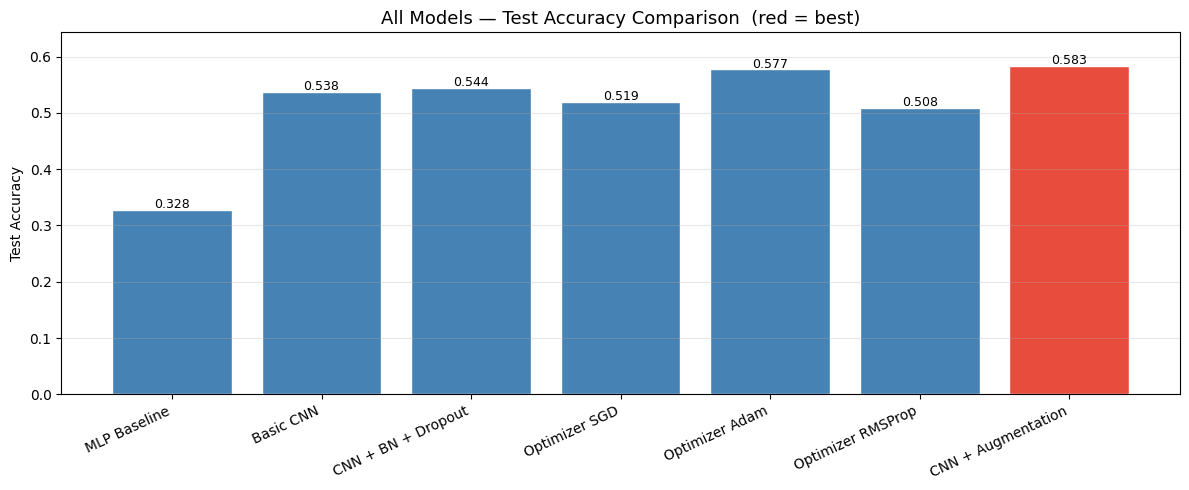

In [26]:
model_names = summary_df['Model'].tolist()
model_accs  = [float(a) for a in summary_df['Test Accuracy'].tolist()]
best_idx    = model_accs.index(max(model_accs))

colors = ['#e74c3c' if i == best_idx else 'steelblue'
          for i in range(len(model_names))]

plt.figure(figsize=(12, 5))
bars = plt.bar(model_names, model_accs, color=colors, edgecolor='white')
for bar, acc in zip(bars, model_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{acc:.3f}', ha='center', fontsize=9)
plt.ylim(0, max(model_accs) + 0.06)
plt.ylabel('Test Accuracy')
plt.title('All Models — Test Accuracy Comparison  (red = best)', fontsize=13)
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Real-World Reflection

### Deployment Challenges
- Real-time inference on a webcam stream works well with our lightweight CNN, but accuracy drops under poor lighting, partial occlusion (glasses, masks), or extreme angles
- MobileNetV2 is designed for mobile, but even it benefits from quantization for true edge deployment (e.g. phones, embedded cameras)

### Bias & Ethical Considerations
- FER-2013 has documented demographic bias — accuracy varies across gender and ethnicity because the dataset isn't balanced across these dimensions
- Deploying emotion recognition in hiring, law enforcement, or surveillance is ethically fraught and actively regulated in several countries
- Emotions are cultural — what reads as "neutral" in one culture may read differently in another; a model trained on this data shouldn't be applied universally

### Data Limitations
- 48×48 pixels loses fine-grained micro-expressions that humans naturally pick up
- Disgust is heavily underrepresented (~1.5% of images) — even with class weights, the model struggles with it
- Images are scraped from the internet, not from natural interaction, so the expressions tend to be exaggerated and staged

In [27]:
# Summary of all saved output files
import glob
saved = sorted(glob.glob('*.png') + glob.glob('*.csv') + glob.glob('*.keras'))
print(f'Best model: {list(results.keys())[model_accs.index(max(model_accs))]}')
print(f'Best accuracy: {max(model_accs):.4f}')
print('\nSaved files:')
for f in saved:
    print(f'  {f}')

Best model: CNN + Augmentation
Best accuracy: 0.5830

Saved files:
  Basic_CNN_confusion.png
  Basic_CNN_curves.png
  CNN_plus_Augmentation_confusion.png
  CNN_plus_Augmentation_curves.png
  CNN_plus_BN_plus_Dropout_confusion.png
  CNN_plus_BN_plus_Dropout_curves.png
  MLP_Baseline_confusion.png
  MLP_Baseline_curves.png
  Optimizer_Adam_confusion.png
  Optimizer_RMSProp_confusion.png
  Optimizer_SGD_confusion.png
  Transfer_Learning_MobileNetV2_curves.png
  Transfer_Learning_confusion.png
  abl_Full_Model_best.keras
  abl_No_Augmentation_best.keras
  abl_No_BatchNorm_best.keras
  abl_No_Dropout_best.keras
  ablation_study.png
  augmentation_examples.png
  class_distribution.png
  cnn1_best.keras
  cnn2_best.keras
  cnn3_best.keras
  cnn3_fixed_best.keras
  failure_cases.png
  mlp_best.keras
  model_comparison.png
  opt_Adam_best.keras
  opt_RMSProp_best.keras
  opt_SGD_best.keras
  optimizer_comparison.png
  results_summary.csv
  sample_images.png
  tl_p1_best.keras
  tl_p2_best.keras